In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mohankrishnathalla_sleep_health_and_daily_performance_dataset_path = kagglehub.dataset_download('mohankrishnathalla/sleep-health-and-daily-performance-dataset')

print('Data source import complete.')


100%|██████████| 4.07M/4.07M [00:00<00:00, 118MB/s]

Extracting files...
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [15]:
# ===============================
# BATCH 1: IMPORTS + LOAD DATA
# ===============================
import pandas as pd
import numpy as np
import os # Import os for path manipulation

# Load dataset
# Assuming 'mohankrishnathalla_sleep_health_and_daily_performance_dataset_path' is available from previous cells.
dataset_dir = mohankrishnathalla_sleep_health_and_daily_performance_dataset_path
csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]

if csv_files:
    csv_file_path = os.path.join(dataset_dir, csv_files[0])
    df = pd.read_csv(csv_file_path)
else:
    raise FileNotFoundError(f"No CSV files found in the dataset directory: {dataset_dir}")

# Basic info
print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (100000, 32)
   person_id  age  gender         occupation   bmi country  \
0          1   29  Female             Driver  25.7   Japan   
1          2   55  Female  Software Engineer  22.0     USA   
2          3   42    Male              Nurse  25.0   India   
3          4   37  Female            Student  29.5   India   
4          5   23    Male             Lawyer  23.6   Spain   

   sleep_duration_hrs  sleep_quality_score  rem_percentage  \
0                6.19                  6.6            22.5   
1                8.32                  6.9            26.9   
2                3.74                  1.0            20.2   
3                6.79                  6.4            17.7   
4                5.02                  3.2            23.3   

   deep_sleep_percentage  ...  heart_rate_resting_bpm  sleep_aid_used  \
0                   19.3  ...                      63               0   
1                   14.9  ...                      52               1   
2              

In [16]:
# ===============================
# BATCH 2: DEFINE TARGET
# ===============================

TARGET_COLUMN = "sleep_disorder_risk"

# Remove leakage columns (VERY IMPORTANT)
leakage_columns = [
    "felt_rested",
    "cognitive_performance_score"
]

# Drop ID if exists
drop_columns = ["person_id"]

df = df.drop(columns=[col for col in drop_columns + leakage_columns if col in df.columns])

# Separate features and target
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100000, 28)
Target shape: (100000,)


In [17]:
# ===============================
# BATCH 3: ENCODING
# ===============================
from sklearn.preprocessing import LabelEncoder

categorical_columns = X.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Encoding done")

Encoding done


In [18]:
# ===============================
# BATCH 4: TRAIN-TEST SPLIT
# ===============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (80000, 28)
Test shape: (20000, 28)


In [19]:
# ===============================
# BATCH 5: SCALING
# ===============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")

Scaling done


In [20]:
# ===============================
# BATCH 6: SMOTE
# ===============================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("Before:", np.bincount(y_train))
print("After:", np.bincount(y_train_resampled))

Before: [43325 26783  6639  3253]
After: [43325 43325 43325 43325]


In [21]:
# ===============================
# BATCH 7: MODEL TRAINING
# ===============================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train_resampled, y_train_resampled)

print("Model trained")

Model trained


In [22]:
# ===============================
# BATCH 8: EVALUATION
# ===============================
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10831
           1       0.94      0.94      0.94      6696
           2       0.69      0.72      0.70      1660
           3       0.83      0.75      0.79       813

    accuracy                           0.94     20000
   macro avg       0.86      0.85      0.86     20000
weighted avg       0.94      0.94      0.94     20000


Confusion Matrix:

[[10754    77     0     0]
 [   72  6294   330     0]
 [    0   348  1190   122]
 [    0     1   201   611]]


                     Feature  Importance
6        sleep_quality_score    0.375009
20   mental_health_condition    0.128472
5         sleep_duration_hrs    0.058478
3                        bmi    0.057279
10   wake_episodes_per_night    0.043648
9         sleep_latency_mins    0.041909
23                shift_work    0.033383
17              stress_score    0.028970
12  alcohol_units_before_bed    0.027048
11    caffeine_mg_before_bed    0.016731


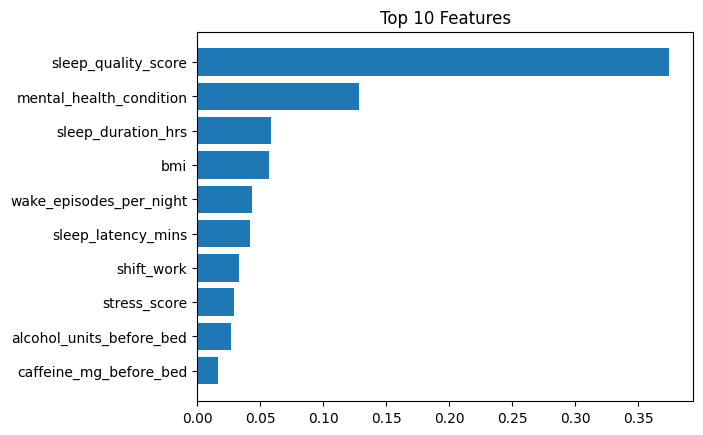

In [23]:
# ===============================
# BATCH 9: FEATURE IMPORTANCE
# ===============================
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

plt.figure()
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Features")
plt.show()

In [24]:
# ===============================
# BATCH 10: SAVE MODEL
# ===============================
import joblib

joblib.dump(model, "sleep_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

print("Model saved successfully")

Model saved successfully


In [28]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import os # Import os for path manipulation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

import joblib


# =========================================
# 2. LOAD DATA
# =========================================
# Assuming 'mohankrishnathalla_sleep_health_and_daily_performance_dataset_path' is available from previous cells.
dataset_dir = mohankrishnathalla_sleep_health_and_daily_performance_dataset_path
csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]

if csv_files:
    csv_file_path = os.path.join(dataset_dir, csv_files[0])
    df = pd.read_csv(csv_file_path)
else:
    raise FileNotFoundError(f"No CSV files found in the dataset directory: {dataset_dir}")

print("Shape:", df.shape)
print(df.head())


# =========================================
# 3. TARGET + CLEANING
# =========================================
TARGET_COLUMN = "sleep_disorder_risk"

# Remove leakage + useless columns
drop_columns = [
    "person_id",
    "felt_rested",
    "cognitive_performance_score"
]

df = df.drop(columns=[col for col in drop_columns if col in df.columns])

# Split
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]


# =========================================
# 4. FEATURE ENGINEERING (IMPORTANT)
# =========================================
X["sleep_efficiency"] = X["sleep_duration_hrs"] * X["sleep_quality_score"]

X["stress_sleep"] = X["stress_score"] * X["sleep_duration_hrs"]

X["lifestyle_risk"] = (
    X["alcohol_units_before_bed"] +
    X["caffeine_mg_before_bed"] +
    X["stress_score"]
)


# =========================================
# 5. ENCODING
# =========================================
categorical_columns = X.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)


# =========================================
# 6. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================
# 7. SCALING
# =========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================================
# 8. SMOTE (BALANCING)
# =========================================
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("Before:", np.bincount(y_train))
print("After:", np.bincount(y_train_resampled))


# =========================================
# 9. CLASS WEIGHTS (EXTRA BOOST)
# =========================================
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

sample_weights = np.array([class_weights[i] for i in y_train_resampled])


# =========================================
# 10. MODEL (LIGHTGBM)
# =========================================
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train_resampled, y_train_resampled, sample_weight=sample_weights)


# =========================================
# 11. EVALUATION
# =========================================
y_pred = model.predict(X_test_scaled)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


# =========================================
# 12. FEATURE IMPORTANCE
# =========================================
importance = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:\n")
print(importance_df.head(10))


# =========================================
# 13. SAVE MODEL
# =========================================
joblib.dump(model, "sleep_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

print("\nModel saved successfully!")

Shape: (100000, 32)
   person_id  age  gender         occupation   bmi country  \
0          1   29  Female             Driver  25.7   Japan   
1          2   55  Female  Software Engineer  22.0     USA   
2          3   42    Male              Nurse  25.0   India   
3          4   37  Female            Student  29.5   India   
4          5   23    Male             Lawyer  23.6   Spain   

   sleep_duration_hrs  sleep_quality_score  rem_percentage  \
0                6.19                  6.6            22.5   
1                8.32                  6.9            26.9   
2                3.74                  1.0            20.2   
3                6.79                  6.4            17.7   
4                5.02                  3.2            23.3   

   deep_sleep_percentage  ...  heart_rate_resting_bpm  sleep_aid_used  \
0                   19.3  ...                      63               0   
1                   14.9  ...                      52               1   
2              

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10831
           1       0.96      0.92      0.94      6696
           2       0.67      0.79      0.72      1660
           3       0.81      0.81      0.81       813

    accuracy                           0.95     20000
   macro avg       0.86      0.88      0.87     20000
weighted avg       0.95      0.95      0.95     20000


Confusion Matrix:

[[10795    36     0     0]
 [   16  6176   503     1]
 [    0   188  1314   158]
 [    0     0   153   660]]

Top Features:

                     Feature  Importance
20   mental_health_condition       11010
5         sleep_duration_hrs        9960
9         sleep_latency_mins        8877
3                        bmi        8609
10   wake_episodes_per_night        8488
17              stress_score        7660
7             rem_percentage        5389
0                        age        4990
12  alcohol_units_before_b